<a href="https://colab.research.google.com/github/gabriel-hohmann/TU-CIS-1051-Final-Project/blob/main/CIS1051FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Import libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
# Load data set from CSV file

df = pd.read_csv('NPORS_2025_for_public_release_FINAL.csv')
df.shape

(5025, 65)

In [6]:
# Defining the parameter of interest: 1 for Donald Trump, 2 for Kamala Harris. Drop 3 for Another Candidate and 99 for No Response

df = df[df['VOTEGEN_POST'].isin([1,2])]

df.drop(df[df['VOTEGEN_POST'].isin([3, 99])].index, inplace=True)

In [7]:
# Filter of chosen survey features that are highly variable and therefore more
# likely to predict voter behavior

survey_response_features = ['ECON1BMOD', 'COMTYPE2', 'UNITY', 'GOVPROTCT', 'MOREGUNIMPACT', 'RELIG', 'BORN', 'RELIMP',
                            'PRAY', 'EDUCCAT', 'RACETHN', 'GENDER', 'METRO']

In [8]:
# Define features and target based on survey

X = df[survey_response_features]
y = df['VOTEGEN_POST']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
# Support Vector Machine Model Results

svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("Support Vector Machine (SVM) Vote Prediction Results:")
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

Support Vector Machine (SVM) Vote Prediction Results:
SVM Accuracy: 0.7631822386679001
Classification Report:
               precision    recall  f1-score   support

         1.0       0.76      0.73      0.74       505
         2.0       0.77      0.80      0.78       576

    accuracy                           0.76      1081
   macro avg       0.76      0.76      0.76      1081
weighted avg       0.76      0.76      0.76      1081

Confusion Matrix:
 [[367 138]
 [118 458]]


In [10]:
# K Nearest Neighbor Model Results

knn = KNeighborsClassifier(n_neighbors=33)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("K-Nearest Neighbors (KNN) Results:")
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

K-Nearest Neighbors (KNN) Results:
KNN Accuracy: 0.8001850138760407
Classification Report:
               precision    recall  f1-score   support

         1.0       0.81      0.74      0.78       505
         2.0       0.79      0.85      0.82       576

    accuracy                           0.80      1081
   macro avg       0.80      0.80      0.80      1081
weighted avg       0.80      0.80      0.80      1081

Confusion Matrix:
 [[376 129]
 [ 87 489]]


In [11]:
# Random Forest Model Results

rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest (RF) Results:")
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest (RF) Results:
Random Forest Accuracy: 0.8714153561517114
Classification Report:
               precision    recall  f1-score   support

         1.0       0.87      0.85      0.86       505
         2.0       0.87      0.89      0.88       576

    accuracy                           0.87      1081
   macro avg       0.87      0.87      0.87      1081
weighted avg       0.87      0.87      0.87      1081

Confusion Matrix:
 [[429  76]
 [ 63 513]]


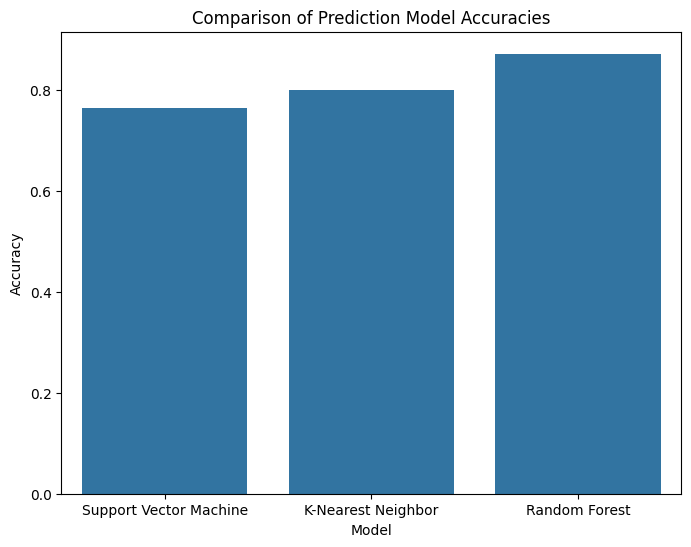

In [12]:
# Data Visualization Comparing Prediction Models

model_names = ['Support Vector Machine', 'K-Nearest Neighbor', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of Prediction Model Accuracies")
plt.show()

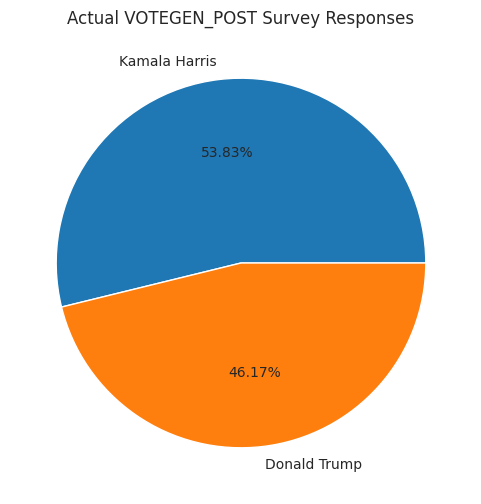

In [13]:
#Pie Chart of Actual Survey Responses

df['VOTEGEN_POST'] = df['VOTEGEN_POST'].replace({1: 'Donald Trump', 2: 'Kamala Harris'})
data = df['VOTEGEN_POST'].value_counts()
labels = data.index
sizes = data.values
sns.set_style("whitegrid")
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.2f%%')
plt.title("Actual VOTEGEN_POST Survey Responses")
plt.show()

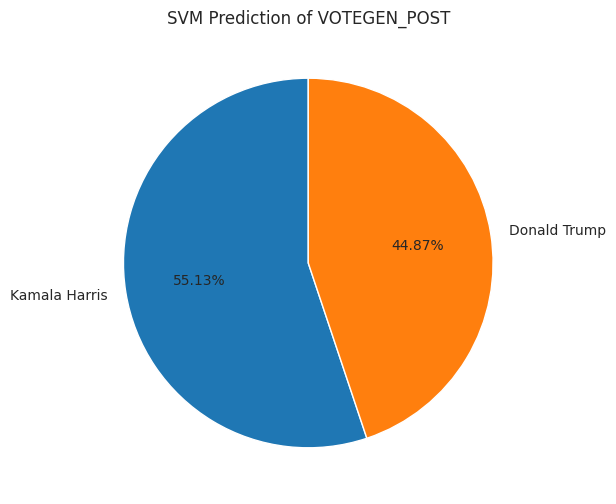

In [14]:
# Pie chart of SVM Prediction

svm_series = pd.Series(y_pred_svm)
svm_prediction = svm_series.value_counts()

# Map numerical predictions to candidate names
svm_labels = svm_prediction.index.map({1.0: 'Donald Trump', 2.0: 'Kamala Harris'})
svm_sizes = svm_prediction.values

# Create pie chart
sns.set_style("whitegrid")
plt.figure(figsize=(6,6))
plt.pie(svm_sizes, labels=svm_labels, autopct='%1.2f%%', startangle=90)
plt.title("SVM Prediction of VOTEGEN_POST")
plt.show()

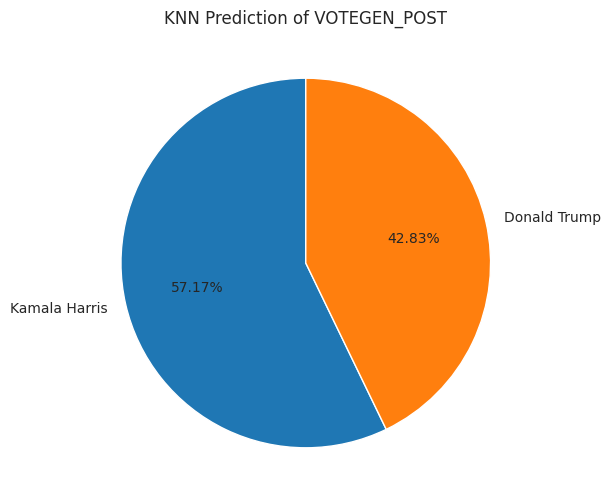

In [15]:
# Pie chart of KNN prediction

knn_prediction = pd.Series(y_pred_knn)
knn = knn_prediction.value_counts()

# Map numerical predictions to candidate names
knn_labels = knn.index.map({1.0: 'Donald Trump', 2.0: 'Kamala Harris'})
knn_sizes = knn.values

# Create pie chart
sns.set_style("whitegrid")
plt.figure(figsize=(6,6))
plt.pie(knn_sizes, labels=knn_labels, autopct='%1.2f%%', startangle=90)
plt.title("KNN Prediction of VOTEGEN_POST")
plt.show()

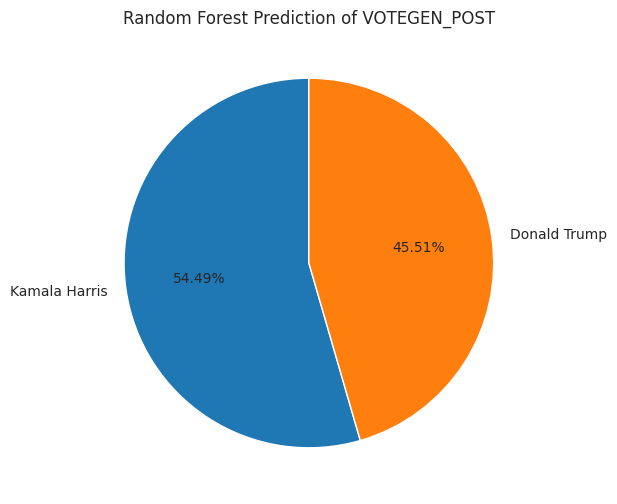

In [16]:
# Pie chart of RF prediction

rf_series = pd.Series(y_pred_rf)
rf_counts = rf_series.value_counts()

# Map numerical predictions to candidate names
rf_labels = rf_counts.index.map({1.0: 'Donald Trump', 2.0: 'Kamala Harris'})
rf_sizes = rf_counts.values

# Create pie chart
.set_style("whitegrid")
plt.figure(figsize=(6,6))
plt.pie(rf_sizes, labels=rf_labels, autopct='%1.2f%%', startangle=90)
plt.title("Random Forest Prediction of VOTEGEN_POST")
plt.show()